# Prediction of Road Accident -- A Kaggle Project by Upamanyu Moitra

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data Loading

In [2]:
df = pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")
df_test = pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")

In [3]:
df.describe()

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849974,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


In [4]:
df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [6]:
df.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [7]:
print(df['road_type'].unique())
print(df['lighting'].unique())
print(df['weather'].unique())
print(df['time_of_day'].unique())

['urban' 'rural' 'highway']
['daylight' 'dim' 'night']
['rainy' 'clear' 'foggy']
['afternoon' 'evening' 'morning']


In [8]:
print(df_test['road_type'].unique())
print(df_test['lighting'].unique())
print(df_test['weather'].unique())
print(df_test['time_of_day'].unique())

['highway' 'urban' 'rural']
['night' 'dim' 'daylight']
['clear' 'foggy' 'rainy']
['afternoon' 'evening' 'morning']


### Data Visulaization

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'num_lanes'}>],
       [<Axes: title={'center': 'curvature'}>,
        <Axes: title={'center': 'speed_limit'}>],
       [<Axes: title={'center': 'num_reported_accidents'}>,
        <Axes: title={'center': 'accident_risk'}>]], dtype=object)

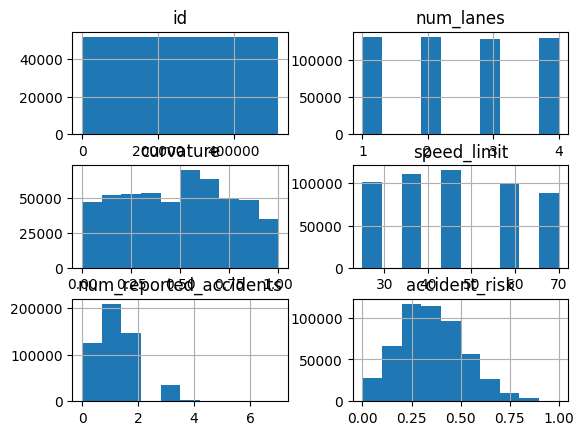

In [9]:
df.hist()

<Axes: >

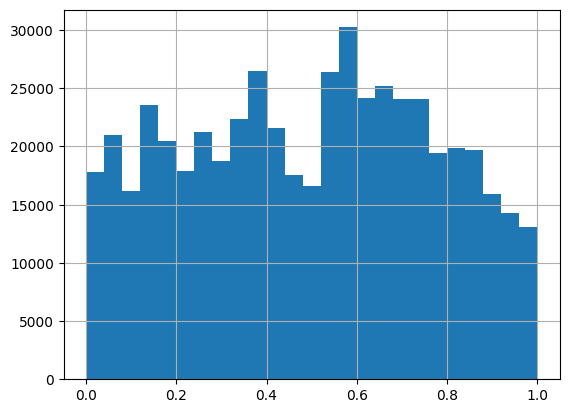

In [10]:
df['curvature'].hist(bins = 25)

<Axes: >

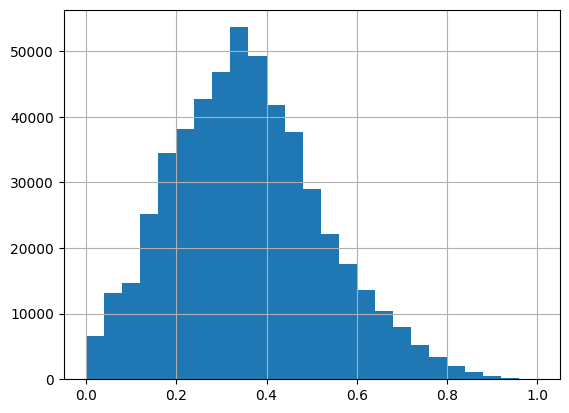

In [11]:
df['accident_risk'].hist(bins = 25)

### Data Transformations

In [12]:
bool_columns = ['road_signs_present', 'public_road', 'holiday', 'school_season']

In [13]:
df[bool_columns] = df[bool_columns].astype(float)
df_test[bool_columns] = df_test[bool_columns].astype(float)

In [14]:
lighting_dict = {'night': 0, 'dim': 1, 'daylight': 2}

In [15]:
df['lighting'] = df['lighting'].map(lighting_dict)

In [16]:
df_test['lighting'] = df_test['lighting'].map(lighting_dict)

In [17]:
print(df.shape)
print(df_test.shape)

(517754, 14)
(172585, 13)


In [18]:
categorical_columns = ['road_type', 'weather', 'time_of_day']

In [19]:
df[categorical_columns]

,road_type,weather,time_of_day
0,urban,rainy,afternoon
1,urban,clear,evening
2,rural,clear,morning
3,highway,rainy,morning
4,rural,foggy,evening
...,...,...,...
517749,highway,foggy,afternoon
517750,rural,rainy,morning
517751,urban,foggy,afternoon
517752,highway,clear,afternoon


In [20]:
from sklearn.preprocessing import OneHotEncoder

In [21]:
oh = OneHotEncoder(sparse_output = False).set_output(transform = 'pandas')

In [22]:
oh_encoded = oh.fit_transform(df[categorical_columns])
oh_test_encoded = oh.transform(df_test[categorical_columns])

In [23]:
df = pd.concat([df, oh_encoded], axis = 1).drop(columns = categorical_columns)

In [24]:
df.head()

,id,num_lanes,curvature,speed_limit,lighting,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk,road_type_highway,road_type_rural,road_type_urban,weather_clear,weather_foggy,weather_rainy,time_of_day_afternoon,time_of_day_evening,time_of_day_morning
0,0,2,0.06,35,2,0.0,1.0,0.0,1.0,1,0.13,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1,4,0.99,35,2,1.0,0.0,1.0,1.0,0,0.35,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,2,4,0.63,70,1,0.0,1.0,1.0,0.0,2,0.30,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,3,4,0.07,35,1,1.0,1.0,0.0,0.0,1,0.21,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,4,1,0.58,60,2,0.0,0.0,1.0,0.0,1,0.56,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [25]:
df_test = pd.concat([df_test, oh_test_encoded], axis = 1).drop(columns = categorical_columns)

In [26]:
df_test.head()

,id,num_lanes,curvature,speed_limit,lighting,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_highway,road_type_rural,road_type_urban,weather_clear,weather_foggy,weather_rainy,time_of_day_afternoon,time_of_day_evening,time_of_day_morning
0,517754,2,0.34,45,0,1.0,1.0,1.0,1.0,1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,517755,3,0.04,45,1,1.0,0.0,1.0,0.0,0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2,517756,2,0.59,35,1,1.0,0.0,1.0,1.0,1,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
3,517757,4,0.95,35,2,0.0,0.0,0.0,0.0,2,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,517758,2,0.86,35,2,1.0,0.0,0.0,1.0,3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [27]:
df.corrwith(df['accident_risk'])

id                        0.000969
num_lanes                -0.006003
curvature                 0.543946
speed_limit               0.430898
lighting                 -0.393860
road_signs_present        0.000629
public_road               0.031032
holiday                   0.051129
school_season            -0.000977
num_reported_accidents    0.213891
accident_risk             1.000000
road_type_highway        -0.011285
road_type_rural          -0.010121
road_type_urban           0.021463
weather_clear            -0.185085
weather_foggy             0.149758
weather_rainy             0.036137
time_of_day_afternoon    -0.004016
time_of_day_evening       0.010032
time_of_day_morning      -0.006019
dtype: float64

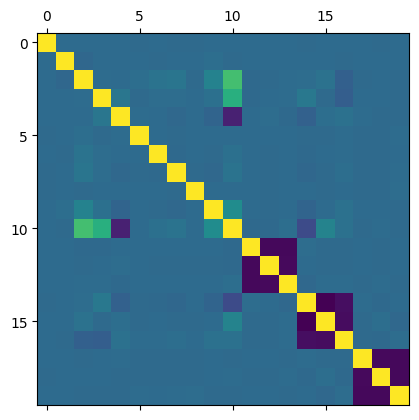

In [28]:
plt.matshow(df.corr())
plt.show()

## Data Splitting

In [29]:
X = df.drop(columns = ['id', 'accident_risk']).values
y = df[['accident_risk']].values
y = y.ravel()

In [30]:
X_test_final = df_test.drop(columns = ['id']).values

In [31]:
print(X.shape, y.shape)
print(X_test_final.shape)

(517754, 18) (517754,)
(172585, 18)


In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size = 0.8, random_state = 137)

# Model Training

### Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [35]:
model_lg = LinearRegression()
model_lg.fit(X_train, y_train)

LinearRegression()

In [36]:
y_pred_lr = model_lg.predict(X_val)
y_pred_lr = y_pred_lr.clip(0, 1)

In [37]:
rmse_lr = mean_squared_error(y_val, y_pred_lr, squared=False)
mae_lr = mean_absolute_error(y_val, y_pred_lr)
r2_lr = r2_score(y_val, y_pred_lr)

In [38]:
print(f"Linear Regression - \n RMSE: {rmse_lr:.4f}, \n MAE: {mae_lr:.4f},\n R2: {r2_lr:.4f}")

Linear Regression - 
 RMSE: 0.0857, 
 MAE: 0.0688,
 R2: 0.7352


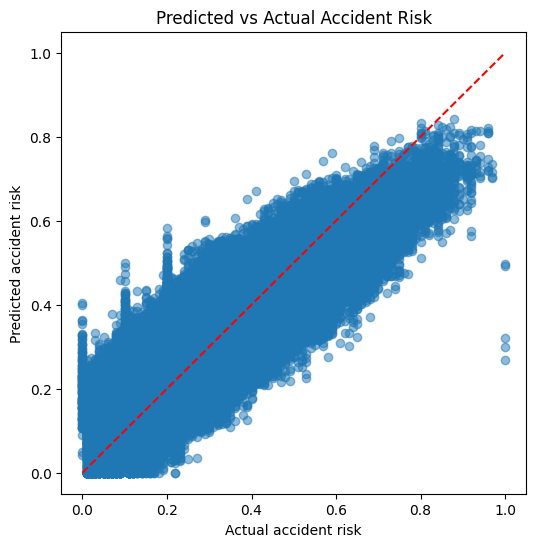

In [39]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred_lr, alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--')  # perfect prediction line
plt.xlabel("Actual accident risk")
plt.ylabel("Predicted accident risk")
plt.title("Predicted vs Actual Accident Risk")
plt.show()

### Elastic Net

In [40]:
from sklearn.linear_model import ElasticNet

In [41]:
model_en = ElasticNet(alpha=0.001, l1_ratio=0.2, random_state=137)  

In [42]:
model_en.fit(X_train, y_train)

ElasticNet(alpha=0.001, l1_ratio=0.2, random_state=137)

In [43]:
y_pred_en = model_en.predict(X_val)
y_pred_en = y_pred_en.clip(0,1)

In [44]:
rmse_en = mean_squared_error(y_val, y_pred_en, squared=False)
mae_en = mean_absolute_error(y_val, y_pred_en)
r2_en = r2_score(y_val, y_pred_en)

In [45]:
print(f"Elastic Net - \n RMSE: {rmse_en:.4f}, \n MAE: {mae_en:.4f},\n R2: {r2_en:.4f}")

Elastic Net - 
 RMSE: 0.0858, 
 MAE: 0.0688,
 R2: 0.7350


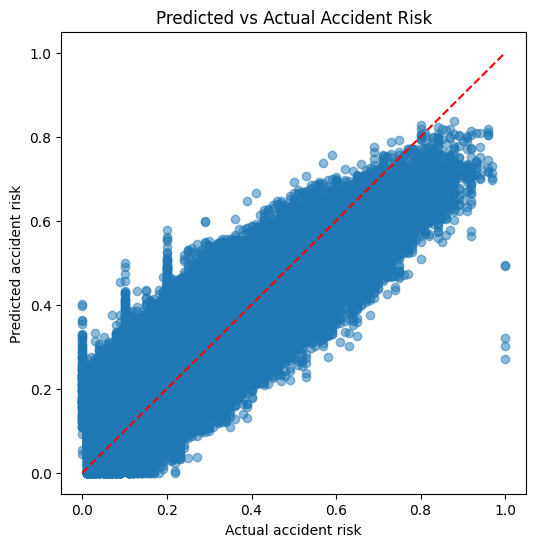

In [46]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred_en, alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--')  # perfect prediction line
plt.xlabel("Actual accident risk")
plt.ylabel("Predicted accident risk")
plt.title("Predicted vs Actual Accident Risk")
plt.show()

## Light GBM

In [47]:
from lightgbm import LGBMRegressor

In [48]:
model_gbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=-1, random_state=137)

In [49]:
model_gbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 176
[LightGBM] [Info] Number of data points in the train set: 414203, number of used features: 18
[LightGBM] [Info] Start training from score 0.352330


LGBMRegressor(learning_rate=0.05, n_estimators=500, random_state=137)

In [50]:
y_pred_gbm = model_gbm.predict(X_val)
y_pred_gbm = y_pred_gbm.clip(0,1)

In [51]:
rmse_gbm = mean_squared_error(y_val, y_pred_gbm, squared=False)
mae_gbm = mean_absolute_error(y_val, y_pred_gbm)
r2_gbm = r2_score(y_val, y_pred_gbm)

In [52]:
print(f"LGBM Regressor - \n RMSE: {rmse_gbm:.4f}, \n MAE: {mae_gbm:.4f},\n R2: {r2_gbm:.4f}")

LGBM Regressor - 
 RMSE: 0.0558, 
 MAE: 0.0435,
 R2: 0.8879


## Neural Network -- Another Take

In [53]:
from tensorflow import keras
from tensorflow.keras import layers

2026-07-13 19:53:54.149133: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783972434.588116      40 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783972434.709963      40 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [54]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

In [55]:
model_nn2 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

I0000 00:00:1783972451.457532      40 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783972451.460385      40 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [56]:
model_nn2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.002),
    loss='mse',
    metrics=['mae']
)

In [57]:
history = model_nn2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100


I0000 00:00:1783972456.133813     109 service.cc:148] XLA service 0x7da8bc003620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783972456.135113     109 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1783972456.135136     109 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1783972456.519387     109 cuda_dnn.cc:529] Loaded cuDNN version 90300


  65/3236 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0577 - mae: 0.1852  

I0000 00:00:1783972458.607040     109 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3236/3236 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 0.0087 - mae: 0.0671 - val_loss: 0.0043 - val_mae: 0.0514 - learning_rate: 0.0020
Epoch 2/100
3236/3236 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0039 - mae: 0.0488 - val_loss: 0.0034 - val_mae: 0.0456 - learning_rate: 0.0020
Epoch 3/100
3236/3236 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0037 - mae: 0.0475 - val_loss: 0.0035 - val_mae: 0.0459 - learning_rate: 0.0020
Epoch 4/100
3236/3236 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0037 - mae: 0.0472 - val_loss: 0.0034 - val_mae: 0.0452 - learning_rate: 0.0020
Epoch 5/100
3236/3236 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0036 - mae: 0.0468 - val_loss: 0.0035 - val_mae: 0.0465 - learning_rate: 0.0020
Epoch 6/100
3236/3236 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0036 - mae: 0.0466 - val_loss: 0.0033 - val_mae: 0.0446 - learning_rate: 0.0020
Epoch 7/100
3236/3236 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0036 - mae: 0.0465 - val_loss: 0.0032 - val_mae: 0.0445 - learning_rate: 0.0

In [58]:
y_pred_nn2 = model_nn2.predict(X_val).flatten()

3236/3236 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [59]:
rmse_nn2 = mean_squared_error(y_val, y_pred_nn2, squared=False)
mae_nn2 = mean_absolute_error(y_val, y_pred_nn2)
r2_nn2 = r2_score(y_val, y_pred_nn2)

In [60]:
print(f"Neural Network 2- \n RMSE: {rmse_nn2:.4f}, \n MAE: {mae_nn2:.4f},\n R2: {r2_nn2:.4f}")

Neural Network 2- 
 RMSE: 0.0569, 
 MAE: 0.0445,
 R2: 0.8834


# Meta Models Prediction

In [61]:
X_meta = np.column_stack((y_pred_gbm, y_pred_nn2))
y_meta = y_val 

In [62]:
from sklearn.linear_model import Ridge

In [63]:
meta_model = Ridge(alpha=1.0) 
meta_model.fit(X_meta, y_meta)

Ridge()

In [64]:
test_preds_lgb = model_gbm.predict(X_test_final)
test_preds_lgb = test_preds_lgb.clip(0,1)
test_preds_nn = model_nn2.predict(X_test_final).flatten()

X_meta_test =   np.column_stack((test_preds_lgb, test_preds_nn))
y_pred_final = meta_model.predict(X_meta_test)
y_pred_final  = y_pred_final.clip(0,1)

5394/5394 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


In [65]:
submission = pd.DataFrame({
    'id': df_test['id'],
    'accident_risk': y_pred_final 
})

In [66]:
submission

,id,accident_risk
0,517754,0.291671
1,517755,0.123867
2,517756,0.185342
3,517757,0.321191
4,517758,0.409616
...,...,...
172580,690334,0.112520
172581,690335,0.518521
172582,690336,0.250689
172583,690337,0.128292


In [67]:
submission.to_csv('submission.csv', index=False)